In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches

import os
os.chdir("/Users/deweywang/Desktop/GitHub/HEVisum/")


# Training data preparation 

In [1]:
import h5py
import numpy as np
import pandas as pd

# =========================
# 設定
# =========================
image_path = "./dataset/elucidata_ai_challenge_data.h5"
spot_path = "./dataset/elucidata_ai_challenge_data.h5"
group_name = "Train"

cell_prefix = ""   # 例如: "zscore_log2_filtered_"，沒有就留空
output = {}        # 存每個 slide 的結果

# =========================
# 開啟 spot 檔案
# =========================
with h5py.File(spot_path, "r") as f:

    slide_ids = list(f[f"spots/{group_name}"].keys())

    for slide_id in slide_ids:
        print(f"Processing slide: {slide_id}")

        # 讀取 spot table
        df = pd.DataFrame(
            np.array(f[f"spots/{group_name}/{slide_id}"])
        )

        # 找出所有 cell type 欄位
        if cell_prefix:
            cell_cols = [c for c in df.columns if c.startswith(cell_prefix)]
        else:
            # 如果沒有 prefix，你可以改成你自己的規則
            # 例如：只要是 C 開頭
            cell_cols = [c for c in df.columns if c.startswith("C")]

        if len(cell_cols) == 0:
            raise ValueError(f"{slide_id} 沒有找到任何 cell type 欄位")

        # =========================
        # 計算每一個 spot 的 cell type 總和
        # =========================
        df["cell_type_sum"] = df[cell_cols].sum(axis=1)

        # 存起來（你也可以直接存成檔案）
        output[slide_id] = df[["x", "y", "cell_type_sum"]]

print("All slides processed.")
output

ModuleNotFoundError: No module named 'h5py'

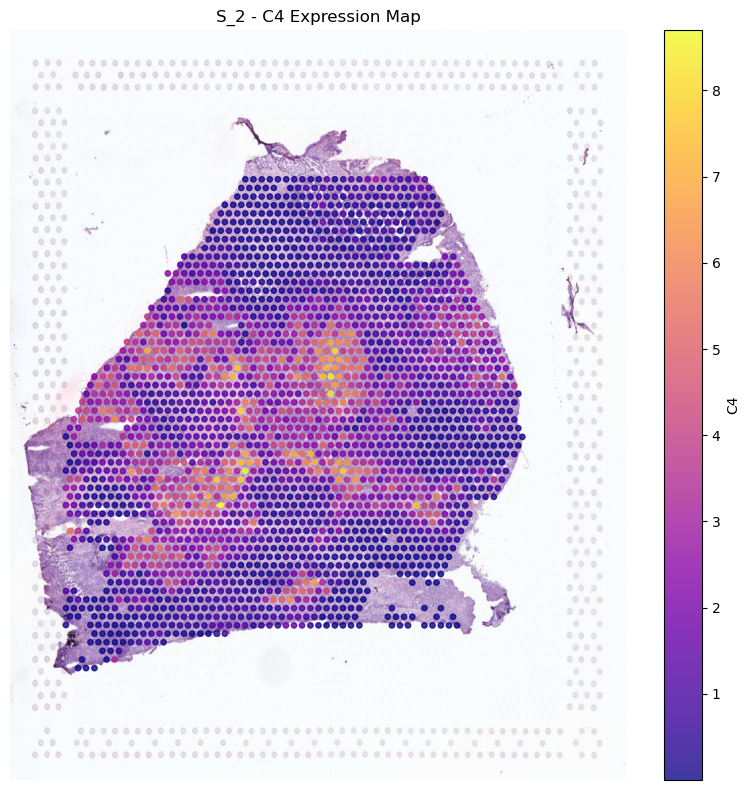

In [8]:

from scripts.plot_expression import plot_cell_expression_on_slide

plot_cell_expression_on_slide(
    slide_id = "S_2",
    cell_type='C4',
    cell_prefix='',
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/try_realign.h5",
    group_name="Train"
)

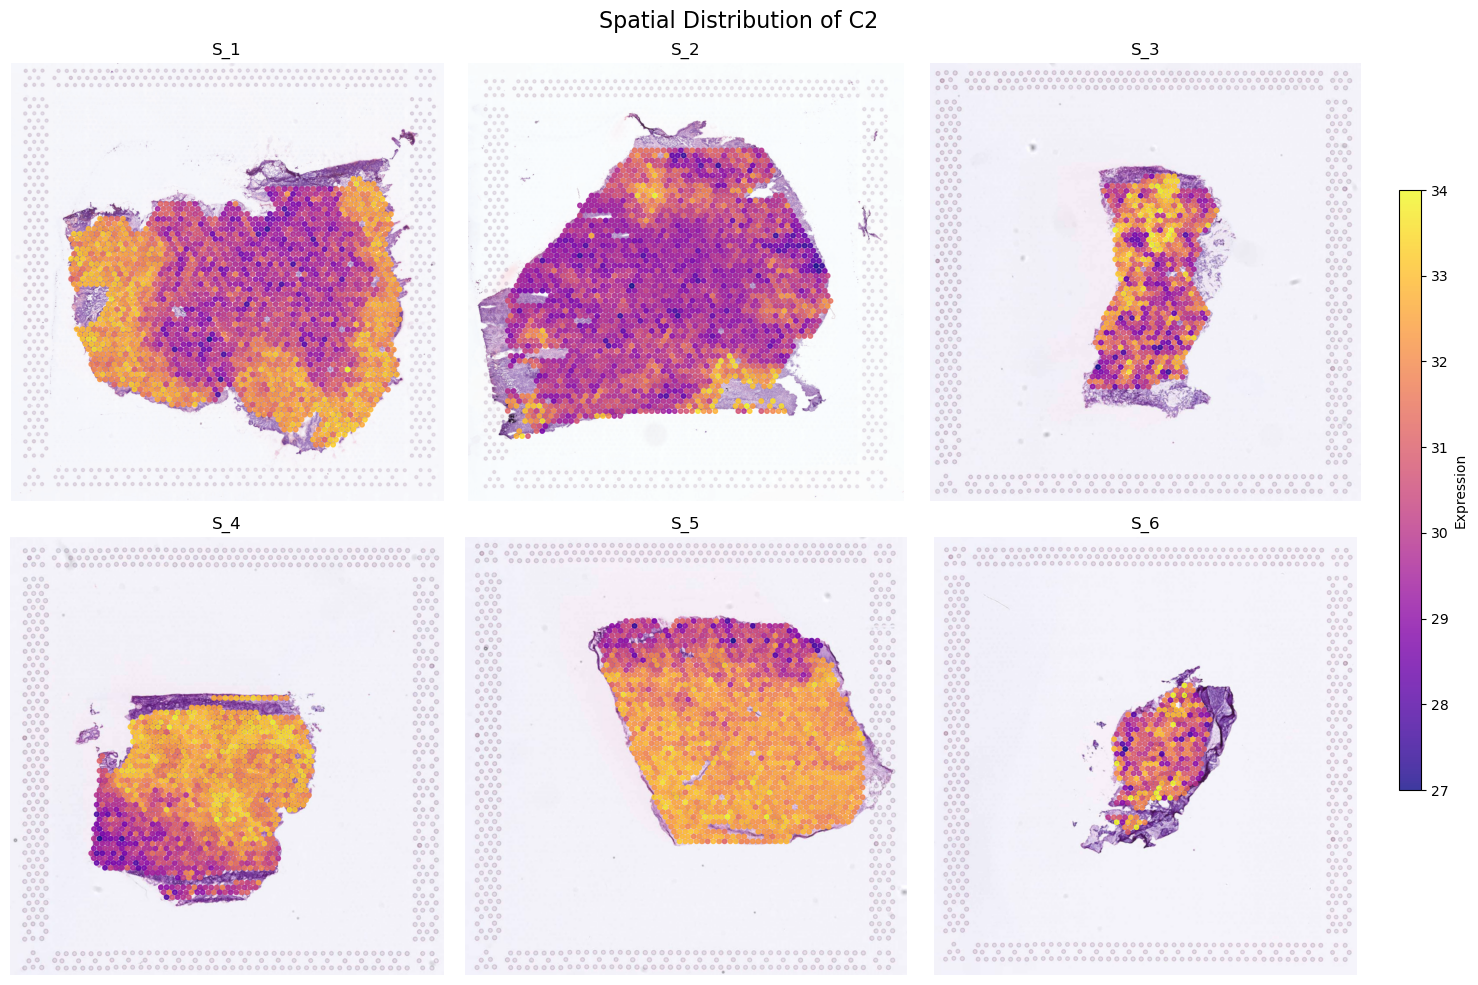

In [17]:
from scripts.plot_expression import plot_cell_expression_all_slides
plot_cell_expression_all_slides(
    cell_short_name='C2',
    cell_prefix='rank_',
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/try_replace_with_rank.h5",
    group_name="Train"
)

/Users/deweywang/Desktop/GitHub/HEVisum/scripts/plot_expression.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.93, 1])


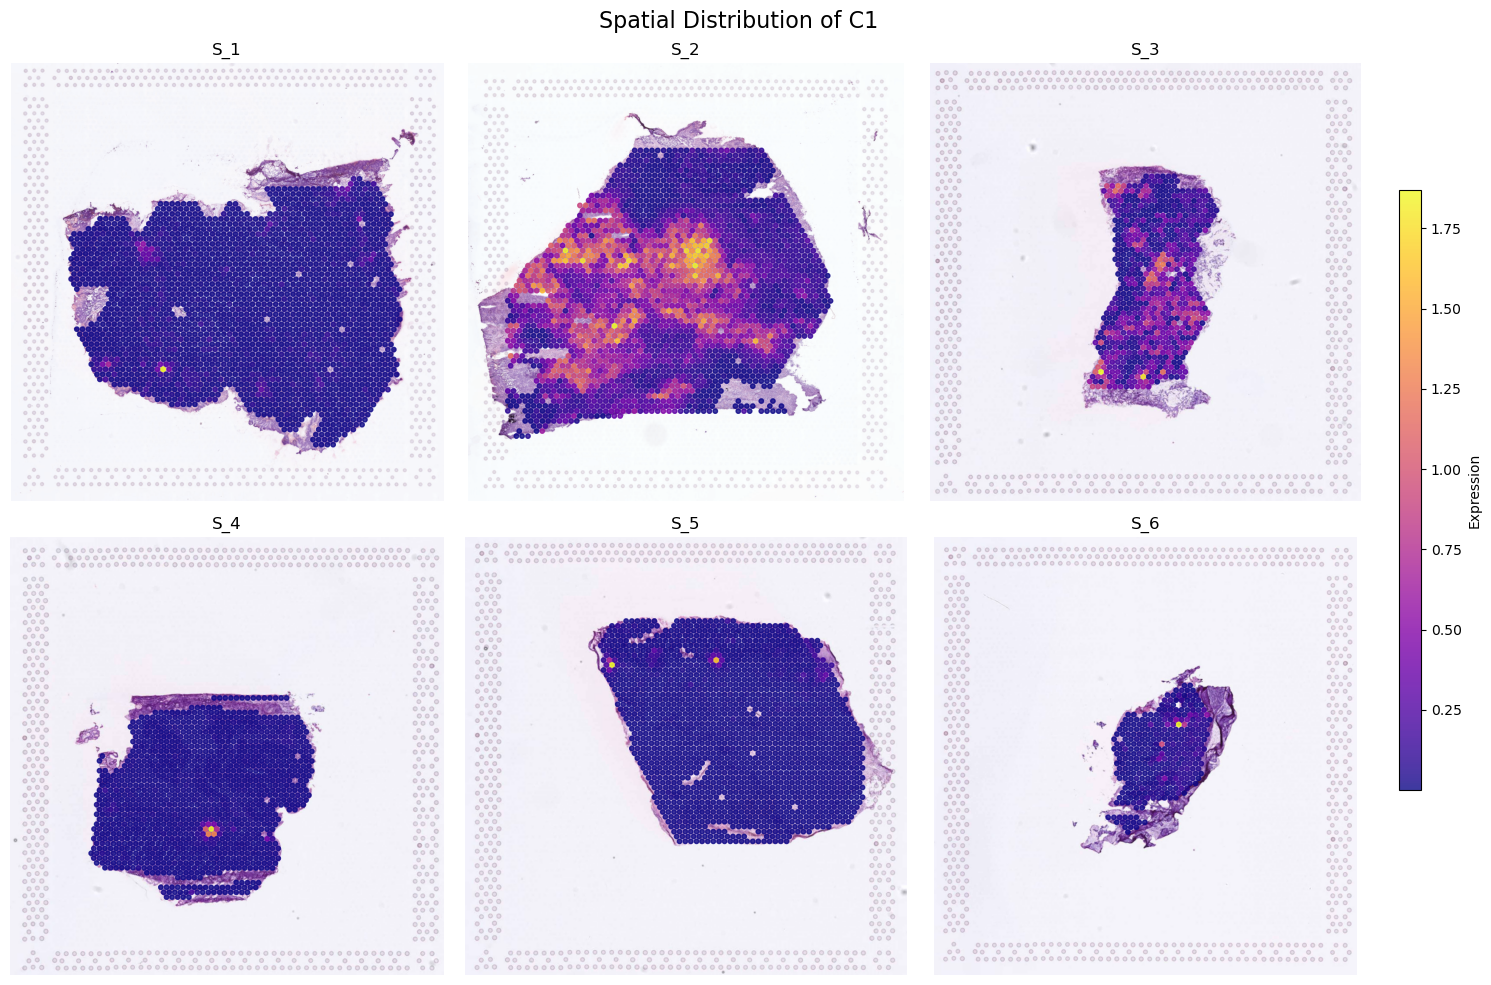

In [2]:
from scripts.plot_expression import plot_cell_expression_all_slides
plot_cell_expression_all_slides(
    cell_short_name='C1',
    cell_prefix='',
    image_path="./dataset/elucidata_ai_challenge_data.h5",
    spot_path="./dataset/try_realign.h5",
    group_name="Train"
)